###Central Limit Theorem

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# !wget --no-check-certificate https://drive.google.com/uc?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo -O weight-height.csv
df_hw = pd.read_csv('D:\\learning\\ScalerDSML\\assets\\weight-height.csv')
print('shape is :',df_hw.shape)
df_hw.head()

shape is : (10000, 3)


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<Axes: xlabel='Height', ylabel='Count'>

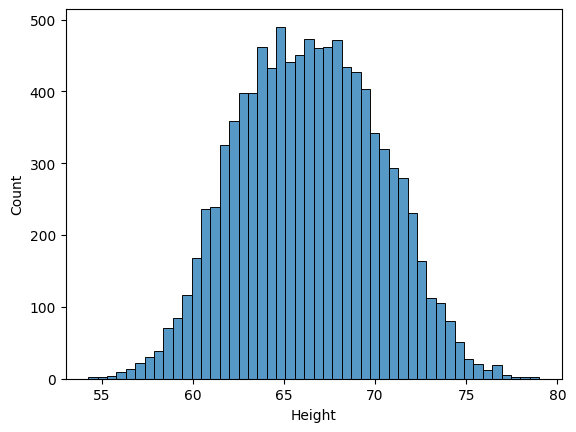

In [10]:
df_height = df_hw["Height"]
sns.histplot(df_height)

In [11]:
pop_mean = df_height.mean()
print(f"The population mean is : {pop_mean}")

pop_std = df_height.std()
print(f"The population standard deviation is : {pop_std}")

The population mean is : 66.36755975482124
The population standard deviation is : 3.847528120773229


### Performing CLT 

In [13]:
df_height.sample(5)

2266    71.170612
2797    71.050918
7112    67.044923
5490    61.698941
253     71.548496
Name: Height, dtype: float64

In [19]:
np.mean(df_height.sample(5))

np.float64(66.13128387845906)

In [21]:
# Generating 1000 sample means of sample size 5
sample_5 = [np.mean(df_height.sample(5)) for i in range(1000)]
sample_5

[np.float64(65.71905358566144),
 np.float64(68.47341399207806),
 np.float64(64.71091921099278),
 np.float64(63.75136461690854),
 np.float64(68.37655345830129),
 np.float64(66.66355816863012),
 np.float64(65.33252018888132),
 np.float64(65.99037920156256),
 np.float64(65.84719483233428),
 np.float64(64.14684289223288),
 np.float64(64.78982584299705),
 np.float64(67.1564536018395),
 np.float64(66.56769750295895),
 np.float64(66.16661974968596),
 np.float64(66.36956365513461),
 np.float64(66.0213924381918),
 np.float64(63.1582639127095),
 np.float64(66.8325632547398),
 np.float64(68.21652937369913),
 np.float64(68.56845325181209),
 np.float64(64.75793248120885),
 np.float64(65.95210493381812),
 np.float64(67.09652888735778),
 np.float64(60.51822418988088),
 np.float64(67.6911816251615),
 np.float64(68.24179202435737),
 np.float64(63.593635915829495),
 np.float64(67.98459058444288),
 np.float64(67.239405892994),
 np.float64(65.9215300217237),
 np.float64(66.32174540229873),
 np.float64(66.

<Axes: ylabel='Count'>

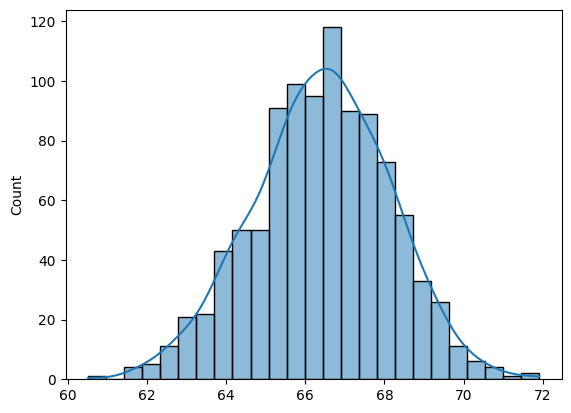

In [22]:
sns.histplot(sample_5,kde=True)

In [23]:
means_of_samp_mean = np.mean(sample_5)
print(f"The means fo the sample mean using CLT is: {means_of_samp_mean}")

pop_mean = df_height.mean()
print(f"The population mean is : {pop_mean}")

The means fo the sample mean using CLT is: 66.40769162769361
The population mean is : 66.36755975482124


In [25]:
sample_20 = [np.mean(df_height.sample(20)) for i in range(1000)]
sample_20

means_of_samp_mean_20 = np.mean(sample_20)
print(f"The means fo the sample mean using CLT with sample size 20 is: {means_of_samp_mean_20}")

pop_mean = df_height.mean()
print(f"The population mean is : {pop_mean}")

The means fo the sample mean using CLT with sample size 20 is: 66.36255717369431
The population mean is : 66.36755975482124


In [29]:
# Set random seed for reproducibility
# np.random.seed(42)

#Parameters
population_size = 100000    # Size of the population
sample_size = 300           # Size of each sample
num_samples = 1000          # Number of samples to draw

# Generate a population with a uniform distribution
population = np.random.uniform(low=0,high=100, size=population_size)

# Array to store the means of samples
sample_means = []

# Draw num_samples samples and calculate their means
for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

<Axes: ylabel='Count'>

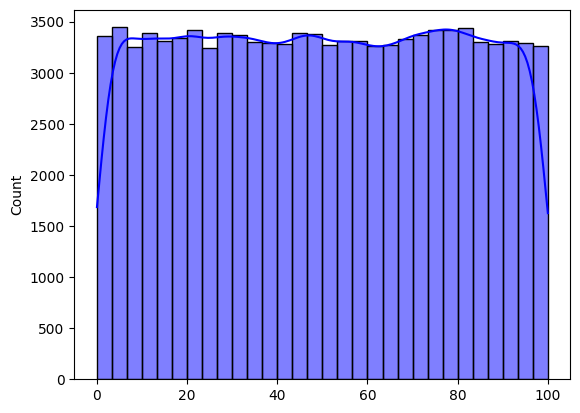

In [30]:
sns.histplot(population, kde=True,color='blue', bins=30)

<Axes: ylabel='Count'>

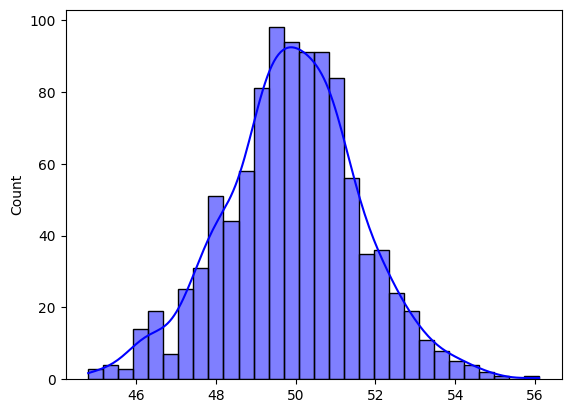

In [31]:
sns.histplot(sample_means, kde=True,color='blue', bins=30)

In [37]:
#mean is 80, find the values less than 75 
from scipy.stats import norm

In [38]:
std_dev =15
mean = 80
num_samples = 50
x=75
std_err = std_dev/np.sqrt(num_samples)
z = (x-mean)/std_err
norm.cdf(z)

np.float64(0.0092110627270495)

In [50]:
import math as math
# Q Calculate estimate with 95% Confidence Interval
confidence_percent = 95
confidence_level = confidence_percent / 100
print(f"Confidence level is : {confidence_level} and confidence percent is : {confidence_percent}%")
print(f"remainging percent is : {100-confidence_percent}%")
z1_level = round(0 + (1-confidence_level)/2,3)
z2_level = round(confidence_level + (1-confidence_level)/2,3)
print(f"Z1 level at {confidence_percent}% confidence level is : {z1_level}")
print(f"Z2 level at {confidence_percent}% confidence level is : {z2_level}")

z1_score = norm.ppf(z1_level)
z2_score = norm.ppf(z2_level)
print(f"Z1 score at {z1_level*100}% confidence level is : {z1_score}")
print(f"Z2 score at {z2_level*100}% confidence level is : {z2_score}")




Confidence level is : 0.95 and confidence percent is : 95%
remainging percent is : 5%
Z1 level at 95% confidence level is : 0.025
Z2 level at 95% confidence level is : 0.975
Z1 score at 2.5% confidence level is : -1.9599639845400545
Z2 score at 97.5% confidence level is : 1.959963984540054


In [54]:
# The mean height of a sample of 100 adults was found to be 65 inches, with standard deviation of 2.5 inches. Compute 95% confidence interval
sample_num = 100
sample_mean = 65
std_dev = 2.5

z1 = norm.ppf(0.025) # 0 + (1-0.95)/2
z2 = norm.ppf(.975) # 0.95 + (1-0.95)/2
print(f"Z1 score is {z1}% and Z2 score is : {z2}")

std_err = std_dev / math.sqrt(sample_num)
x1  = sample_mean + z1*std_err
x2  = sample_mean + z2*std_err
print(f"The 95% confidence interval is between : {x1} and {x2}")

print(f"The 95% confidence interval is between : {norm.interval(0.95, loc=sample_mean, scale=std_err)}")

Z1 score is -1.9599639845400545% and Z2 score is : 1.959963984540054
The 95% confidence interval is between : 64.51000900386498 and 65.48999099613502
The 95% confidence interval is between : (np.float64(64.51000900386498), np.float64(65.48999099613502))


In [60]:
sample_num = 80
sample_mean = 45
std_dev = 10
confidence_percent = 90
confidence_level = confidence_percent / 100

z1 = norm.ppf( 0 + (1-confidence_level)/2) 
z2 = norm.ppf( confidence_level + (1-confidence_level)/2)
print(f"Z1 score is {z1}% and Z2 score is : {z2}")

std_err = std_dev / math.sqrt(sample_num)
x1  = sample_mean + z1*std_err
x2  = sample_mean + z2*std_err
print(f"Calculate:      The {confidence_percent}% confidence interval is between : {x1} and {x2}")

print(f"norm.interval:  The {confidence_percent}% confidence interval is between : {norm.interval(confidence_level, loc=sample_mean, scale=std_err)}")

Z1 score is -1.6448536269514729% and Z2 score is : 1.6448536269514722
Calculate:      The 90% confidence interval is between : 43.16099773854971 and 46.83900226145029
norm.interval:  The 90% confidence interval is between : (np.float64(43.16099773854971), np.float64(46.83900226145029))
